<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.4 Tensão tangencial máxima. Círculo de Mohr.

## Problema 4 <a name="PI44"></a>

Considere o estado de tensão em redor do elemento infinitesimal centrado no ponto $P$ que é representado
na Figura.

[a)](#A) Desenhe o círculo de Mohr para o estado de tensão representado, assinalando os pontos
	correspondentes às faces respectivamente perpendiculares aos eixos $x$ e $y$, o valor da tensão
	tangencial máxima e as tensões principais do estado de tensão.

[b)](#B) Determine as direcções principais do estado de tensão em P e escreva a matriz
 de transformação que transforma o referencial $S_0(O,\vec{\imath},
 \vec{\jmath},\vec{k})$ da figura no referencial principal
 $S_p(O,\vec{\imath}_p,\vec{\jmath}_p,\vec{k}_p)$.

[c)](#C) Considere agora que $\sigma_{zz}$ é diferente de zero e determine a gama de valores de $\sigma_{zz}$ para a qual a
	tensão tangencial máxima se mantém inferior a 140 MPa.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au04/Au04_P004_i1.jpg"
width="400" height="160">

## Resolução

#### a) Desenhe o círculo de Mohr para o estado de tensão representado, assinalando os pontos correspondentes às faces respectivamente perpendiculares aos eixos $x$ e $y$, o valor da tensão tangencial máxima e as tensões principais do estado de tensão.<a name="A"></a>

([enunciatum](#PI44))

A matriz de tensão expressa no referencial $S(0,x,y,z)$ vem:

\begin{equation*}
\sigma_{ji} = [\sigma]^\top =
\begin{bmatrix}
180 & 80 & 0 \\
80 & 60 & 0 \\
0 & 0 & 0
\end{bmatrix}~\textrm{MPa}
\end{equation*}

A tensão $\sigma_{zz} = 0$ MPa é uma tensão principal de tensão e a direção dos eixos dos $zz$ é uma direção principal de tensão.

Em estado plano de tensão as leis de transformação entre componentes da matriz das tensões vem expressa por:

\begin{equation*}
\begin{aligned}
\sigma_{x'x'} &= \frac{\sigma_{xx} + \sigma_{yy} }{2} + \frac{\sigma_{xx} - \sigma_{yy} }{2} \cos2\theta -
\tau_{xy}\sin2\theta \\
\sigma_{y'y'} &= \frac{\sigma_{xx} + \sigma_{yy} }{2} - \frac{\sigma_{xx} - \sigma_{yy} }{2} \cos2\theta -
\tau_{xy}\sin2\theta \\
\tau_{x'x'} &= \frac{\sigma_{yy} - \sigma_{xx} }{2} \sin2\theta + \tau_{xy}\cos2\theta \\
\end{aligned}
\end{equation*}

Pelo primeiro invariante das tensões se obtem:

\begin{equation*}
\sigma_{xx} + \sigma_{yy} = \sigma_{x'x'} + \sigma_{y'y'}
\end{equation*}

Matriz das tensões tt0 = 
 [[180  80   0]
 [ 80  60   0]
 [  0   0   0]]
-----------------
PLANO x-z:
-----------------
Tensões (normais) principais: -------------------------------------------
angPrincipal (deg) = 26.57
tens xx - plano principal [1] = 220.00  MPa
tens yy - plano principal [1] = 20.00  MPa
tens xy - plano principal [1] = 0.00  MPa

angPrincipal 2 (deg) = 116.57
tens xx - plano principal [2] = 20.00  MPa
tens yy - plano principal [2] = 220.00  MPa
tens xy - plano principal [2] = 0.00  MPa

Tensões de corte maximas/mínima: -------------------------------------------
Ângulo tensão corte max (Deg) = -18.43
tens xx - plano  tensão de corte min (MPa) = 120.00
tens yy - plano  tensão de corte max (MPa) = 120.00
tens xy - plano  tensão de corte max (MPa) = 100.00
Ângulo tensão corte min (Deg) = 71.57
tens xx - plano  tensão de corte min (MPa) = 120.00
tens yy - plano  tensão de corte min (MPa) = 120.00
tens xy - plano  tensão de corte min (MPa) = -100.00


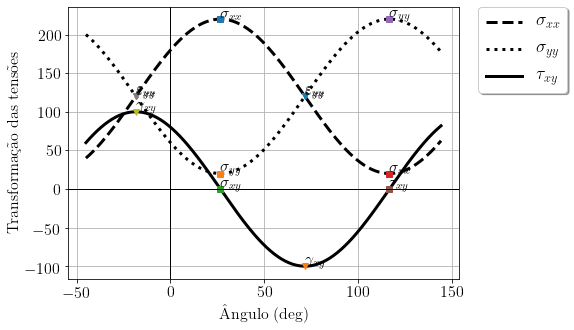

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
# rc('text', usetex=True)

def TensorTensoes(s11,s12,s13,s22,s23,s33):
    s21 = s12; s31 = s13; s32 = s23
    return np.array([[s11,s12,s13], [s21,s22,s23], [s31,s32,s33]])

tt0 = TensorTensoes(180,80,0,60,0,0) # unidade: MPa
print('Matriz das tensões tt0 = \n',tt0)

def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

print('-----------------')
print('PLANO x-z:')
print('-----------------')
sxx = tt0[0,0]
syy = tt0[1,1]
txy = tt0[0,1]

angt = np.arange(-45,145,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

print('Tensões (normais) principais: -------------------------------------------')
aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal (deg) =','{:.2f}'.format(aprinc))
tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens xx - plano principal [1] =','{:.2f}'.format(tsxx1),' MPa')
print('tens yy - plano principal [1] =','{:.2f}'.format(tsyy1),' MPa')
print('tens xy - plano principal [1] =','{:.2f}'.format(ttxy1),' MPa')

aprinc2 = aprinc + 90
print('\nangPrincipal 2 (deg) =','{:.2f}'.format(aprinc2))
tsxx2 = sxx1(sxx,syy,txy,np.deg2rad(aprinc2))
tsyy2 = syy1(sxx,syy,txy,np.deg2rad(aprinc2))
ttxy2 = txy1(sxx,syy,txy,np.deg2rad(aprinc2))
print('tens xx - plano principal [2] =','{:.2f}'.format(tsxx2),' MPa')
print('tens yy - plano principal [2] =','{:.2f}'.format(tsyy2),' MPa')
print('tens xy - plano principal [2] =','{:.2f}'.format(np.abs(ttxy2)),' MPa')

print('\nTensões de corte maximas/mínima: -------------------------------------------')
aS1 = angS(sxx,syy,txy)/2 # ângulo no espaço físico, radianos
print('Ângulo tensão corte max (Deg) =','{:.2f}'.format(np.rad2deg(aS1)))
tcortexxMa = sxx1(sxx,syy,txy,aS1)
tcorteyyMa = syy1(sxx,syy,txy,aS1)
tcortexyMa = txy1(sxx,syy,txy,aS1)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMa))
print('tens yy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcorteyyMa))
print('tens xy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexyMa))

aS2 = aS1 + np.pi/2
print('Ângulo tensão corte min (Deg) =','{:.2f}'.format(np.rad2deg(aS2)))
tcortexxMb = sxx1(sxx,syy,txy,aS2)
tcorteyyMb = syy1(sxx,syy,txy,aS2)
tcortexyMb = txy1(sxx,syy,txy,aS2)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMb))
print('tens yy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcorteyyMb))
print('tens xy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexyMb))

# use LaTeX fonts in the plot
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=3)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
# points: principal stresses
ax.plot(aprinc, tsxx1, 's'), ax.text(aprinc, tsxx1,r'$\sigma_{xx}$')
ax.plot(aprinc, tsyy1, 's'), ax.text(aprinc, tsyy1,r'$\sigma_{yy}$')
ax.plot(aprinc, ttxy1, 's'), ax.text(aprinc, ttxy1,r'$\sigma_{xy}$')
ax.plot(aprinc2, tsxx2, 's'), ax.text(aprinc2, tsxx2,r'$\sigma_{xx}$')
ax.plot(aprinc2, tsyy2, 's'), ax.text(aprinc2, tsyy2,r'$\sigma_{yy}$')
ax.plot(aprinc2, ttxy2, 's'), ax.text(aprinc2, ttxy2,r'$\tau_{xy}$')
# points: critical shear stresses
ax.plot(np.rad2deg(aS1), tcortexxMa, 'v')
ax.text(np.rad2deg(aS1), tcortexxMa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS1), tcorteyyMa, 'v')
ax.text(np.rad2deg(aS1), tcorteyyMa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS1), tcortexyMa, 'v')
ax.text(np.rad2deg(aS1), tcortexyMa,r'$\gamma_{xy}$')
ax.plot(np.rad2deg(aS2), tcortexxMb, 'v')
ax.text(np.rad2deg(aS2), tcortexxMb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS2), tcorteyyMb, 'v')
ax.text(np.rad2deg(aS2), tcorteyyMb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS2), tcortexyMb, 'v')
ax.text(np.rad2deg(aS2), tcortexyMb,r'$\gamma_{xy}$')

ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()


PLANO x-y:
  Tensão normal mínima:  20.0
  Tensão normal máxima:  220.0
  Tensão normal média :  120.0
Tensão de corte mínima:  -100.0
Tensão de corte máxima:  100.0
Ponto A ( 180.0 , 80.0 )
Ponto B ( 60.0 , -80.0 )

Tensão principal 1: 220.00  MPa
Tensão principal 2: 20.00  MPa
Tensão principal 3: 0.00  MPa


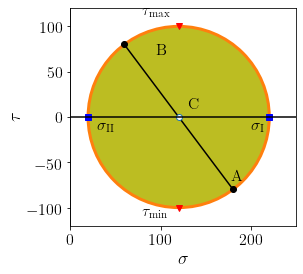

In [66]:
def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print("  Tensão normal mínima: ", np.round(Smin,6))
    print("  Tensão normal máxima: ", np.round(Smax, 6))
    print("  Tensão normal média : ", np.round(center[0], 6))
    print("Tensão de corte mínima: ", np.round(-radius, 6))
    print("Tensão de corte máxima: ", np.round(radius, 6))

    print('Ponto A (','{:.1f}'.format(S11),',','{:.1f}'.format(S12),')')
    print('Ponto B (','{:.1f}'.format(S22),',','{:.1f}'.format(-S12),')')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [-S12, S12], 'ko')
    plt.plot([S11, S22], [-S12, S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S11 - .2*desv, -S12 + desv , 'A')
    plt.text(S22 + 3.5*desv, S12 - 1*desv, 'B')
    plt.text(Smin + .1*radius, -0.15*radius, r'$\sigma_\mathrm{II}$')
    plt.text(Smax - .2*radius, -0.15*radius, r'$\sigma_\mathrm{I}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[0,250],[-120,120]])
print('\n================================')
print('PLANO x-y:')
print('================================')
sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]
S = np.array([[sxx, sxy],[sxy, syy]])
mohr(S, axislim)

center = (sxx + syy)/2
radius = np.sqrt((sxx - syy)**2/4.0 + sxy**2)
smax = center + radius
smin = center - radius
print('\nTensão principal 1:','{:.2f}'.format(smax),' MPa')
print('Tensão principal 2:','{:.2f}'.format(smin),' MPa')
print('Tensão principal 3:','{:.2f}'.format(tt0[2,2]),' MPa')

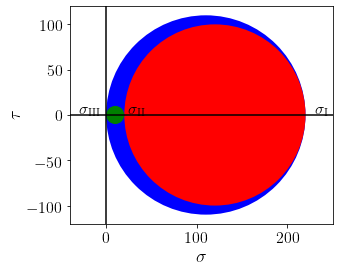

In [67]:
def circleradius(S):
    S11 = S[0,0]
    S12 = S[0,1]
    S22 = S[1,1]

    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)

    return center, radius

limits = np.array([[-40,250],[-120,120]])

sigI = smax
sigII = smin
sigIII = tt0[2,2]

s11 = sigI; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center1, radius1  = circleradius(S)

s11 = sigI; s22 = sigII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center2, radius2  = circleradius(S)

s11 = sigII; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center3, radius3  = circleradius(S)

circ1 = plt.Circle((center1[0],0), radius1, facecolor='b')
circ2 = plt.Circle((center2[0],0), radius2, facecolor='r')
circ3 = plt.Circle((center3[0],0), radius3, facecolor='g')

plt.axis('image'); ax = plt.gca()

plt.gcf().gca().add_artist(circ1)
plt.gcf().gca().add_artist(circ2)
plt.gcf().gca().add_artist(circ3)

plt.xlabel(r"$\sigma$", size=18)
plt.ylabel(r"$\tau$", size=18)

plt.text(1.05*sigI, 0, r'$\sigma_\mathrm{I}$')
plt.text(1.2*sigII, 0, r'$\sigma_\mathrm{II}$')
plt.text(-1.5*sigII, 0, r'$\sigma_\mathrm{III}$')

plt.xlim(limits[0,0],limits[0,1])
plt.ylim(limits[1,0],limits[1,1])

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

#### b) Determine as direcções principais do estado de tensão em P e escreva a matriz de transformação que transforma o referencial $S_0(O,\vec{\imath}, \vec{\jmath},\vec{k})$ da figura no referencial principal  $S_p(O,\vec{\imath}_p,\vec{\jmath}_p,\vec{k}_p)$.<a name="B"></a>

([enunciatum](#PI44))

In [68]:
print('\n Calculo dos invariantes pela matriz das tensões  : ............................')

I1 = np.trace(tt0)
print('1º Invariante, I1:', '{:.1f}'.format(I1))

I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.1f}'.format(I2))

I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

print('\n Resolucao Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Roots = ',-np.sort(-valpropriosN))

sI = valpropriosN[0]
print('Tensão principal sI : ',sI,' MPa')
sII = valpropriosN[1]
print('Tensão principal sII : ',sII,' MPa')
sIII = valpropriosN[2]
print('Tensão principal sIII : ',sIII,' MPa')


 Calculo dos invariantes pela matriz das tensões  : ............................
1º Invariante, I1: 240.0
2º Invariante, I2 : 4400.0
3º Invariante, I3 : 0.0

 Resolucao Numerica - Numpy : ............................

 Roots =  [220.  20.   0.]
Tensão principal sI :  220.0  MPa
Tensão principal sII :  20.0  MPa
Tensão principal sIII :  0.0  MPa


In [69]:
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (tt0[0,0] - vp)*d1 + tt0[0,1]*d2 + tt0[0,2]*d3
def eq2(d1,d2,d3,vp): return tt0[1,0]*d1 + (tt0[1,1] - vp)*d2 + tt0[1,2]*d3
def eq3(d1,d2,d3,vp): return tt0[2,0]*d1 + tt0[2,1]*d2 + (tt0[2,2] - vp)*d3
def eq4(d1,d2,d3): return d1**2 + d2**2 + d3**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

# 1 valor proprio -------------------
print('\nVetor próprio associado a sI = ','{:.2f}'.format(sI),'.............................')
print('\n(i) sistema de equações:')
E1_sI = eq1(d1,d2,d3,sI); print(E1_sI,' = 0')
E2_sI = eq2(d1,d2,d3,sI); print(E2_sI,' = 0')
E3_sI = eq3(d1,d2,d3,sI); print(E3_sI,' = 0')
E4_sI = eq4(d1,d2,d3); print(E4_sI,' = 0')
VetProp1 = solve([E1_sI,E3_sI,E4_sI], [d1,d2,d3], dict=True)
l1 = float(VetProp1[1][d1])
m1 = float(VetProp1[1][d2])
n1 = float(VetProp1[1][d3])
versorI = versor(l1,m1,n1)
print('\n (iii) vec{nI} = (','{:.3f}'.format(l1),') e1 + (','{:.3f}'.format(m1),') e2 + (','{:.3f}'.format(n1),') e3')


Vetor próprio associado a sI =  220.00 .............................

(i) sistema de equações:
-40.0*d1 + 80*d2  = 0
80*d1 - 160.0*d2  = 0
-220.0*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (iii) vec{nI} = ( 0.894 ) e1 + ( 0.447 ) e2 + ( 0.000 ) e3


In [70]:
# 2 valor proprio -------------------
print('\nVetor próprio associado a sII= ','{:.2f}'.format(sII),' .............................')
print('\n (i) sistema de equações:')
E1_sII = eq1(d1,d2,d3,sII); print(E1_sII,' = 0')
E2_sII = eq2(d1,d2,d3,sII); print(E2_sII,' = 0')
E3_sII = eq3(d1,d2,d3,sII); print(E3_sII,' = 0')
E4_sII = eq4(d1,d2,d3); print(E4_sII,' = 0')
VetProp2 = solve([E1_sII,E3_sII,E4_sII], [d1,d2,d3], dict=True)
l2 = float(VetProp2[0][d1])
m2 = float(VetProp2[0][d2])
n2 = float(VetProp2[0][d3])
versorII = versor(l2,m2,n2)
print('\n (iii) vec{nII} = (','{:.3f}'.format(l2),') e1 + (','{:.3f}'.format(m2),') e2 + (','{:.3f}'.format(n2),') e3')


Vetor próprio associado a sII=  20.00  .............................

 (i) sistema de equações:
160.0*d1 + 80*d2  = 0
80*d1 + 40.0*d2  = 0
-20.0*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (iii) vec{nII} = ( -0.447 ) e1 + ( 0.894 ) e2 + ( 0.000 ) e3


In [71]:
# 3 valor proprio -------------------
print('\nVetor próprio associado a sIII= ','{:.2f}'.format(sIII),' .............................')
print('\n (i) sistema de equações:')
E1_sIII = eq1(d1,d2,d3,sIII); print(E1_sIII,' = 0')
E2_sIII = eq2(d1,d2,d3,sIII); print(E2_sIII,' = 0')
E3_sIII = eq3(d1,d2,d3,sIII); print(E3_sIII,' = 0')
E4_sIII = eq4(d1,d2,d3); print(E4_sIII,' = 0')
VetProp3 = solve([E1_sIII,E2_sIII,E4_sIII], [d1,d2,d3], dict=True)
l3 = float(VetProp3[1][d1])
m3 = float(VetProp3[1][d2])
n3 = float(VetProp3[1][d3])
versorIII = versor(l3,m3,n3)
print('\n (iii) vec{nIII} = (','{:.3f}'.format(l3),') e1 + (','{:.3f}'.format(m3),') e2 + (','{:.3f}'.format(n3),') e3')


Vetor próprio associado a sIII=  0.00  .............................

 (i) sistema de equações:
180.0*d1 + 80*d2  = 0
80*d1 + 60.0*d2  = 0
0  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (iii) vec{nIII} = ( 0.000 ) e1 + ( 0.000 ) e2 + ( 1.000 ) e3


In [72]:
print('\n Versores - verificação de ortogonalidade: ')
print('dot(vp1,vp1) = ','{:.1f}'.format(np.dot(versorI,versorI)))
print('dot(vp2,vp2) = ', '{:.1f}'.format(np.dot(versorII,versorII)))
print('dot(vp3,vp3) = ', '{:.1f}'.format(np.dot(versorIII,versorIII)))
print('dot(vp1,vp2) = ', '{:.0f}'.format(np.dot(versorI,versorII)))
print('dot(vp2,vp3) = ', np.dot(versorII,versorIII))
print('dot(vp1,vp3) = ', '{:.0f}'.format(np.abs(np.dot(versorI,versorIII))))

np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

print('\n Àngulo entre eI e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

mT = np.concatenate((versorI, versorII,versorIII))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ','{:.2f}'.format(np.linalg.det(mT)))


 Versores - verificação de ortogonalidade: 
dot(vp1,vp1) =  1.0
dot(vp2,vp2) =  1.0
dot(vp3,vp3) =  1.0
dot(vp1,vp2) =  0
dot(vp2,vp3) =  0.0
dot(vp1,vp3) =  0

 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre eI e x: 

 theta_P =  26.57  Deg

 [T] = 
 [[ 0.894  0.447  0.   ]
 [-0.447  0.894  0.   ]
 [ 0.     0.     1.   ]]

[T][T]^T = I :
 [[ 1.000e+00 -1.259e-17  0.000e+00]
 [-1.259e-17  1.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  1.000e+00]]

 det(T) =  1.00


In [73]:
def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]

aP1 = angP(sxx,syy,sxy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI  = ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI  =  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

angulos das direções principais

No espaço das tensões:
angPI  =  53.130  deg |  0.927  radians
angPII =  233.130  deg |  4.069  radians

No espaço fisico:
angPI  =   26.565  deg |  0.464  radians
angPII =  116.565  deg |  2.034  radians

Matriz de transformação = 
 [[ 0.894  0.447  0.   ]
 [-0.447  0.894  0.   ]
 [ 0.     0.     1.   ]]

Vetores principais:
eI =  [0.894 0.447 0.   ]
eII =  [-0.447  0.894  0.   ]
eIII =  [0. 0. 1.]


####  c) Considere agora que $\sigma_{zz}$ é diferente de zero e determine a gama de valores de $\sigma_{zz}$ para a qual a tensão tangencial máxima se mantém inferior a 140 MPa.<a name="C"></a>

([enunciatum](#PI44))

Considerando a inequação para a tensão de corte: $\tau_\mathrm{max} < 140$ MPa. A componente $\sigma_{zz}$ é uma direção
 principal de tensão. Esta poderá assumir valores para os quais se pode verificar:
 $\sigma_{zz} = \sigma_{\mathrm{I}} ~ \vee \sigma_{zz} = \sigma_{\mathrm{III}}$.

##### Caso I: $\sigma_{zz} = \sigma_{\mathrm{I}}$

\begin{equation*}
\begin{cases}
\sigma_{\mathrm{II}} & = & 220 ~\textrm{MPa}\\
\sigma_{\mathrm{III}} & = & 20 ~\textrm{MPa}\\
\end{cases}
\end{equation*}

 resultando,

\begin{equation*}
\frac{ \sigma_{\mathrm{I}}- \sigma_{\mathrm{III}} }{2} <140 \quad \Leftrightarrow \quad
\sigma_{\mathrm{I}} (\sigma_{zz}) < 300~\textrm{MPa}
\end{equation*}

##### Caso II: $\sigma_{zz} = \sigma_{\mathrm{III}}$

\begin{equation*}
\begin{cases}
\sigma_{\mathrm{I}} & = & 220 ~\textrm{MPa}\\
\sigma_{\mathrm{II}} & = & 20 ~\textrm{MPa}\\
\end{cases}
\end{equation*}

 resultando,

\begin{equation*}
\frac{ \sigma_{\mathrm{I}}- \sigma_{\mathrm{III}} }{2} <140 \quad \Leftrightarrow \quad
\sigma_{\mathrm{III}} (\sigma_{zz}) > -60~\textrm{MPa}
\end{equation*}

In [74]:
tmax = 140
s1, s3 = symbols('s1 s3')

def taumax(s1,s3): return (s1-s3)/2
s2 = 220
s3n = s3.subs({s3:20})

szz_caseI = solve([taumax(s1,s3n) - tmax], [s1], dict=True)
print('Case I ------------------------------------- ')
print('sigma I = ',szz_caseI[0][s1])
print('sigma II = ',s2)
print('sigma III = ',s3n)

s1n = s1.subs({s1:220})
s2 = 20

szz_caseII = solve([taumax(s1n,s3) - tmax], [s3], dict=True)
print('Case II ------------------------------------- ')
print('sigma I = ',s1n)
print('sigma II = ',s2)
print('sigma III = ',szz_caseII[0][s3])


Case I ------------------------------------- 
sigma I =  300
sigma II =  220
sigma III =  20
Case II ------------------------------------- 
sigma I =  220
sigma II =  20
sigma III =  -60


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>